In [1]:
from functools import reduce
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.categories import subcat_to_cat

import pickle

In [ ]:
def get_preds_tuple(method_name, cfg, dataset_name, n_shots, seq_no) -> (str, str):
    run_name = f'{method_name}-cfg{cfg}-{dataset_name}_{n_shots}sh'
    run_path = rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\{method_name}_1b-cfg{cfg}-TRACE-seq{seq_no}-{dataset_name}-{n_shots}sh.bin'

    return run_name, run_path

In [ ]:
# preds_path_ls = [
#     ('raw 0 shot',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_0sh.bin'),
#     ('raw 5 shot',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_5sh.bin'),
#     ('LoRA 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg13_0sh.bin'),
#     ('LoRA 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg13_5sh.bin'),
#     ('GSOFT 0 shot', r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg0_0sh.bin'),
#     ('GSOFT 5 shot', r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg0_5sh.bin'),
# ]

# preds_path_ls = [
#     ('raw 0 shot',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_0sh.bin'),
#     ('raw 5 shot',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_5sh.bin'),
#     ('LoRA 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg17_0sh.bin'),
#     ('LoRA 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg17_5sh.bin'),
#     ('LoRA-code 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg18-code-ift-MMLU_0sh.bin'),
#     ('LoRA-code 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg18-code-ift-MMLU_5sh.bin'),
#     ('GSOFT-code 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg3-code-ift-MMLU_0sh.bin'),
#     ('GSOFT-code 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg3-code-ift-MMLU_5sh.bin'),
#     # ('LoRA-CR 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg18-OOD-MMLU_0sh.bin'),
#     # ('LoRA-CR 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA-cfg18-OOD-MMLU_5sh.bin'),
#     # ('DoRA-CR 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\DoRA-cfg18-OOD-MMLU_0sh.bin'),
#     # ('DoRA-CR 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\DoRA-cfg18-OOD-MMLU_5sh.bin'),
#     # ('GSOFT-CR 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg3-OOD-MMLU_0sh.bin'),
#     # ('GSOFT-CR 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT-cfg3-OOD-MMLU_5sh.bin'),
#     # ('VeRA-CR 0 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\VeRA-cfg1-OOD-MMLU_0sh.bin'),
#     # ('VeRA-CR 5 shot',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\VeRA-cfg1-OOD-MMLU_5sh.bin'),
# ]

All_dataset_names = ['20Minuten', 'FOMC', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'NumGLUE-cm', 'Py150']                       # Benchmarks in use
# dataset_names = ['20Minuten', 'FOMC', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'NumGLUE-cm', 'Py150']
dataset_names = ['20Minuten', 'FOMC', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'NumGLUE-cm']

LoRA_cfgs = [2, 5, 6]
GSOFT_cfgs = [2, 3]
SemiLoRA_cfgs = [1, 2]
HydraLoRA_cfgs = [1]
seq_no = 1

preds_path_ls = [
    ('Raw_0sh',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_1b_0sh.bin'),
    ('Raw_5sh',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_1b_5sh.bin'),
    # ('LoRA_1b-CR',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA_1b-cfg{LoRA_cfg}-CR_5sh.bin'),
    # ('GSOFT_1b-CR',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT_1b-cfg{GSOFT_cfg}-CR_5sh.bin'),
]

for n_shots in (0, 5):
    for dataset_name in dataset_names:
        preds_path_ls.append(
            (f'LoRA-{dataset_name}_{n_shots}sh',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA_1b-cfg{LoRA_cfg}-TRACE-seq{seq_no}-{dataset_name}-{n_shots}sh.bin'),
        )

    for dataset_name in dataset_names:
        preds_path_ls.append(
            (f'SemiLoRA-{dataset_name}_{n_shots}sh',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\SemiLoRA_1b-cfg{SemiLoRA_cfg}-TRACE-seq{seq_no}-{dataset_name}-{n_shots}sh.bin'),
        )

    for dataset_name in dataset_names:
        preds_path_ls.append(
            (f'HydraLoRA-{dataset_name}_{n_shots}sh',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\HydraLoRA_1b-cfg{HydraLoRA_cfg}-TRACE-seq{seq_no}-{dataset_name}-{n_shots}sh.bin'),
        )

    for dataset_name in dataset_names:
        preds_path_ls.append(
            (f'GSOFT-{dataset_name}_{n_shots}sh',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT_1b-cfg{GSOFT_cfg}-TRACE-seq{seq_no}-{dataset_name}-{n_shots}sh.bin'),
        )

# max_step = 16_000
# for st in range(2_000, max_step+1, 2_000):
#     preds_path_ls.append(
#         (f'LoRA_1b-code st-{st}',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA_1b-cfg{LoRA_cfg}-st{st}-MMLU_5sh.bin')
#     )

# for st in range(2_000, max_step+1, 2_000):
#     preds_path_ls.append(
#         (f'GSOFT_1b-code st-{st}',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT_1b-cfg{GSOFT_cfg}-st{st}-MMLU_5sh.bin')
#     )

In [3]:
preds_dfs = {}

for run_name, preds_path in preds_path_ls:
    with open(preds_path, 'rb') as f:
        preds_dfs[run_name] = pickle.load(file=f)

        print(f"{run_name:16}: {preds_dfs[run_name].shape=}")

Raw_0sh         : preds_dfs[run_name].shape=(14042, 7)
Raw_5sh         : preds_dfs[run_name].shape=(14042, 7)
LoRA-20Minuten_0sh: preds_dfs[run_name].shape=(14042, 7)
LoRA-FOMC_0sh   : preds_dfs[run_name].shape=(14042, 7)
LoRA-NumGLUE-ds_0sh: preds_dfs[run_name].shape=(14042, 7)
LoRA-ScienceQA_0sh: preds_dfs[run_name].shape=(14042, 7)
LoRA-C-STANCE_0sh: preds_dfs[run_name].shape=(14042, 7)
LoRA-NumGLUE-cm_0sh: preds_dfs[run_name].shape=(14042, 7)
SemiLoRA-20Minuten_0sh: preds_dfs[run_name].shape=(14042, 7)
SemiLoRA-FOMC_0sh: preds_dfs[run_name].shape=(14042, 7)
SemiLoRA-NumGLUE-ds_0sh: preds_dfs[run_name].shape=(14042, 7)
SemiLoRA-ScienceQA_0sh: preds_dfs[run_name].shape=(14042, 7)
SemiLoRA-C-STANCE_0sh: preds_dfs[run_name].shape=(14042, 7)
SemiLoRA-NumGLUE-cm_0sh: preds_dfs[run_name].shape=(14042, 7)
HydraLoRA-20Minuten_0sh: preds_dfs[run_name].shape=(14042, 7)
HydraLoRA-FOMC_0sh: preds_dfs[run_name].shape=(14042, 7)
HydraLoRA-NumGLUE-ds_0sh: preds_dfs[run_name].shape=(14042, 7)
Hydra

In [4]:
idx = 6

print(preds_dfs['Raw_5sh']['text'][idx])
print(preds_dfs['Raw_5sh']['model_pred'][idx])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

The following are multiple choice questions (with answers) about abstract_algebra. Output 'A', 'B', 'C', or 'D'. Full answer not needed.<|eot_id|><|start_header_id|>user<|end_header_id|>

Find all c in Z_3 such that Z_3[x]/(x^2 + c) is a field.
A. 0
B. 1
C. 2
D. 3<|eot_id|><|start_header_id|>assistant<|end_header_id|>

B<|eot_id|><|start_header_id|>user<|end_header_id|>

Statement 1 | If aH is an element of a factor group, then |aH| divides |a|. Statement 2 | If H and K are subgroups of G then HK is a subgroup of G.
A. True, True
B. False, False
C. True, False
D. False, True<|eot_id|><|start_header_id|>assistant<|end_header_id|>

B<|eot_id|><|start_header_id|>user<|end_header_id|>

Statement 1 | Every element of a group generates a cyclic subgroup of the group. Statement 2 | The symmetric group S_10 has 10 elements.
A. True, True
B. False, False
C. True, False
D. False, True<|eot_id|><|start_header_id|>assistant<|end_header_i

In [5]:
# tmp_idxs = preds_dfs['Raw 1b 0 shot']['model_pred'].apply(
#     lambda p: re.match('[ABCD]', p['generated_text']) is not None
# )

# preds_dfs['Raw 1b 0 shot']['model_pred'][~tmp_idxs].shape

In [6]:
def get_category(subject):
    return subcat_to_cat[subject]

# OOD_part = re.compile('The correct answer is [ABCD]')
# OOD_part_len = len('The correct answer is ')

OOD_parts = [
    (re.compile('The correct answer is [ABCD]'), len('The correct answer is ')),
    (re.compile('The answer is [ABCD]'), len('The answer is ')),
    (re.compile('The solution is [ABCD]'), len('The solution is ')),
]

def get_pred(p):
    for OOD_part, OOD_part_len in OOD_parts:
        if OOD_part.search(p):
            return p[OOD_part_len]
    
    return p[0]

def processor(row: pd.DataFrame):
    generated_text = row['model_pred']['generated_text']
    generated_text = generated_text.strip()
    

    # generated_text	subject	pred	true	corr	category
    category = get_category(row['subject'])
    pred = get_pred(generated_text)
    true = chr(ord('A') + row['answer'])
    corr = int(pred == true)

    return {
        'generated_text': generated_text,
        'subject': row['subject'],
        'pred': pred,
        'true': true,
        'corr': corr,
        'category': category
    }

In [7]:
print(*preds_dfs.keys(), sep='\n')

Raw_0sh
Raw_5sh
LoRA-20Minuten_0sh
LoRA-FOMC_0sh
LoRA-NumGLUE-ds_0sh
LoRA-ScienceQA_0sh
LoRA-C-STANCE_0sh
LoRA-NumGLUE-cm_0sh
SemiLoRA-20Minuten_0sh
SemiLoRA-FOMC_0sh
SemiLoRA-NumGLUE-ds_0sh
SemiLoRA-ScienceQA_0sh
SemiLoRA-C-STANCE_0sh
SemiLoRA-NumGLUE-cm_0sh
HydraLoRA-20Minuten_0sh
HydraLoRA-FOMC_0sh
HydraLoRA-NumGLUE-ds_0sh
HydraLoRA-ScienceQA_0sh
HydraLoRA-C-STANCE_0sh
HydraLoRA-NumGLUE-cm_0sh
GSOFT-20Minuten_0sh
GSOFT-FOMC_0sh
GSOFT-NumGLUE-ds_0sh
GSOFT-ScienceQA_0sh
GSOFT-C-STANCE_0sh
GSOFT-NumGLUE-cm_0sh
LoRA-20Minuten_5sh
LoRA-FOMC_5sh
LoRA-NumGLUE-ds_5sh
LoRA-ScienceQA_5sh
LoRA-C-STANCE_5sh
LoRA-NumGLUE-cm_5sh
SemiLoRA-20Minuten_5sh
SemiLoRA-FOMC_5sh
SemiLoRA-NumGLUE-ds_5sh
SemiLoRA-ScienceQA_5sh
SemiLoRA-C-STANCE_5sh
SemiLoRA-NumGLUE-cm_5sh
HydraLoRA-20Minuten_5sh
HydraLoRA-FOMC_5sh
HydraLoRA-NumGLUE-ds_5sh
HydraLoRA-ScienceQA_5sh
HydraLoRA-C-STANCE_5sh
HydraLoRA-NumGLUE-cm_5sh
GSOFT-20Minuten_5sh
GSOFT-FOMC_5sh
GSOFT-NumGLUE-ds_5sh
GSOFT-ScienceQA_5sh
GSOFT-C-STANCE_5sh
GSOFT

In [8]:
for run_name in preds_dfs.keys():
    preds_dfs[run_name] = preds_dfs[run_name].apply(processor, axis=1, result_type='expand')

In [9]:
preds_dfs['Raw_5sh'].head()

,generated_text,subject,pred,true,corr,category
0,C,abstract_algebra,C,B,0,STEM
1,C,abstract_algebra,C,C,1,STEM
2,C,abstract_algebra,C,D,0,STEM
3,C,abstract_algebra,C,B,0,STEM
4,To find the product of the given polynomials i...,abstract_algebra,T,B,0,STEM


In [10]:
# preds_dfs['LoRA_1b-CR'].head()

In [11]:
acc_by_subjects = pd.DataFrame({
    'subject': list(set.union(
        *map(
            lambda df: set(df['subject']),
            preds_dfs.values()
        )
    ))
})

print(f"Subjects: {acc_by_subjects['subject']}")

for run_name, preds_df in preds_dfs.items():
    acc_df = preds_df[['subject', 'corr']].groupby(['subject'], as_index=False).mean()
    acc_df.rename(columns={'corr': run_name}, inplace=True)

    acc_by_subjects = acc_by_subjects.merge(
        acc_df,
        left_on='subject',
        right_on='subject',
        how='right'
    )

Subjects: 0                college_computer_science
1                       international_law
2                  high_school_statistics
3                      conceptual_physics
4                 professional_psychology
5                        security_studies
6                       us_foreign_policy
7                        public_relations
8              high_school_microeconomics
9                  high_school_us_history
10                         moral_disputes
11                              astronomy
12                 electrical_engineering
13                           formal_logic
14                    high_school_biology
15                      logical_fallacies
16                           econometrics
17                       professional_law
18                             management
19                          jurisprudence
20                          miscellaneous
21                high_school_mathematics
22                        college_biology
23                  high

In [12]:
acc_by_subjects

,subject,Raw_0sh,Raw_5sh,LoRA-20Minuten_0sh,LoRA-FOMC_0sh,LoRA-NumGLUE-ds_0sh,LoRA-ScienceQA_0sh,LoRA-C-STANCE_0sh,LoRA-NumGLUE-cm_0sh,SemiLoRA-20Minuten_0sh,...,HydraLoRA-NumGLUE-ds_5sh,HydraLoRA-ScienceQA_5sh,HydraLoRA-C-STANCE_5sh,HydraLoRA-NumGLUE-cm_5sh,GSOFT-20Minuten_5sh,GSOFT-FOMC_5sh,GSOFT-NumGLUE-ds_5sh,GSOFT-ScienceQA_5sh,GSOFT-C-STANCE_5sh,GSOFT-NumGLUE-cm_5sh
0,abstract_algebra,0.010000,0.260000,0.010000,0.310000,0.280000,0.220000,0.290000,0.300000,0.010000,...,0.260000,0.250000,0.220000,0.170000,0.220000,0.340000,0.320000,0.310000,0.280000,0.290000
1,anatomy,0.325926,0.488889,0.251852,0.488889,0.503704,0.511111,0.496296,0.503704,0.392593,...,0.525926,0.503704,0.451852,0.459259,0.503704,0.503704,0.511111,0.525926,0.496296,0.518519
2,astronomy,0.230263,0.526316,0.085526,0.394737,0.453947,0.500000,0.440789,0.434211,0.164474,...,0.394737,0.388158,0.328947,0.355263,0.552632,0.519737,0.532895,0.513158,0.486842,0.506579
3,business_ethics,0.370000,0.500000,0.120000,0.420000,0.490000,0.480000,0.400000,0.420000,0.290000,...,0.460000,0.480000,0.390000,0.370000,0.460000,0.500000,0.520000,0.470000,0.490000,0.510000
4,clinical_knowledge,0.298113,0.486792,0.237736,0.407547,0.467925,0.501887,0.403774,0.392453,0.290566,...,0.433962,0.426415,0.290566,0.294340,0.486792,0.494340,0.505660,0.498113,0.494340,0.490566
5,college_biology,0.305556,0.430556,0.131944,0.430556,0.486111,0.458333,0.430556,0.416667,0.104167,...,0.402778,0.451389,0.340278,0.381944,0.479167,0.465278,0.486111,0.472222,0.437500,0.437500
6,college_chemistry,0.010000,0.270000,0.000000,0.260000,0.320000,0.370000,0.280000,0.280000,0.000000,...,0.360000,0.320000,0.240000,0.250000,0.270000,0.220000,0.220000,0.250000,0.230000,0.250000
7,college_computer_science,0.180000,0.240000,0.020000,0.320000,0.380000,0.420000,0.360000,0.370000,0.050000,...,0.370000,0.310000,0.310000,0.300000,0.280000,0.290000,0.300000,0.190000,0.270000,0.270000
8,college_mathematics,0.040000,0.240000,0.000000,0.250000,0.260000,0.310000,0.300000,0.320000,0.010000,...,0.250000,0.380000,0.260000,0.270000,0.250000,0.270000,0.310000,0.240000,0.240000,0.250000
9,college_medicine,0.225434,0.393064,0.092486,0.352601,0.387283,0.398844,0.369942,0.375723,0.104046,...,0.404624,0.346821,0.312139,0.323699,0.393064,0.381503,0.421965,0.393064,0.358382,0.387283


In [13]:
acc_by_categories = pd.DataFrame({
    'category': list(set.union(
        *map(
            lambda df: set(df['category']),
            preds_dfs.values()
        )
    ))
})

for run_name, preds_df in preds_dfs.items():
    acc_df = preds_df[['category', 'corr']].groupby(['category'], as_index=False).mean()
    acc_df.rename(columns={'corr': run_name}, inplace=True)

    acc_by_categories = acc_by_categories.merge(
        acc_df,
        left_on='category',
        right_on='category',
        how='right'
    )

In [14]:
acc_by_categories.loc[:, list(filter(
    lambda s: ('5 shot' not in s),
    acc_by_categories.columns
))]

,category,Raw_0sh,Raw_5sh,LoRA-20Minuten_0sh,LoRA-FOMC_0sh,LoRA-NumGLUE-ds_0sh,LoRA-ScienceQA_0sh,LoRA-C-STANCE_0sh,LoRA-NumGLUE-cm_0sh,SemiLoRA-20Minuten_0sh,...,HydraLoRA-NumGLUE-ds_5sh,HydraLoRA-ScienceQA_5sh,HydraLoRA-C-STANCE_5sh,HydraLoRA-NumGLUE-cm_5sh,GSOFT-20Minuten_5sh,GSOFT-FOMC_5sh,GSOFT-NumGLUE-ds_5sh,GSOFT-ScienceQA_5sh,GSOFT-C-STANCE_5sh,GSOFT-NumGLUE-cm_5sh
0,STEM,0.168323,0.358516,0.041750,0.323393,0.340954,0.384361,0.344268,0.344268,0.078860,...,0.352220,0.350563,0.298542,0.305500,0.362160,0.364480,0.375083,0.348575,0.333333,0.343605
1,humanities,0.349628,0.414665,0.059724,0.361530,0.396599,0.404676,0.348565,0.354304,0.341339,...,0.363443,0.348565,0.243358,0.253773,0.416153,0.401700,0.409564,0.340489,0.313284,0.342827
2,"other (business, health, misc.)",0.373843,0.502468,0.214374,0.430907,0.499075,0.525910,0.417952,0.414250,0.323257,...,0.463294,0.456508,0.347625,0.353486,0.504935,0.495065,0.511721,0.508637,0.484886,0.489204
3,social sciences,0.370816,0.488463,0.142671,0.386415,0.470263,0.500812,0.410790,0.408515,0.261618,...,0.444264,0.448489,0.336692,0.344166,0.492038,0.479038,0.486513,0.490738,0.465063,0.477738


In [15]:
acc_by_categories.loc[:, list(filter(
    lambda s: ('0 shot' not in s),
    acc_by_categories.columns
))]

,category,Raw_0sh,Raw_5sh,LoRA-20Minuten_0sh,LoRA-FOMC_0sh,LoRA-NumGLUE-ds_0sh,LoRA-ScienceQA_0sh,LoRA-C-STANCE_0sh,LoRA-NumGLUE-cm_0sh,SemiLoRA-20Minuten_0sh,...,HydraLoRA-NumGLUE-ds_5sh,HydraLoRA-ScienceQA_5sh,HydraLoRA-C-STANCE_5sh,HydraLoRA-NumGLUE-cm_5sh,GSOFT-20Minuten_5sh,GSOFT-FOMC_5sh,GSOFT-NumGLUE-ds_5sh,GSOFT-ScienceQA_5sh,GSOFT-C-STANCE_5sh,GSOFT-NumGLUE-cm_5sh
0,STEM,0.168323,0.358516,0.041750,0.323393,0.340954,0.384361,0.344268,0.344268,0.078860,...,0.352220,0.350563,0.298542,0.305500,0.362160,0.364480,0.375083,0.348575,0.333333,0.343605
1,humanities,0.349628,0.414665,0.059724,0.361530,0.396599,0.404676,0.348565,0.354304,0.341339,...,0.363443,0.348565,0.243358,0.253773,0.416153,0.401700,0.409564,0.340489,0.313284,0.342827
2,"other (business, health, misc.)",0.373843,0.502468,0.214374,0.430907,0.499075,0.525910,0.417952,0.414250,0.323257,...,0.463294,0.456508,0.347625,0.353486,0.504935,0.495065,0.511721,0.508637,0.484886,0.489204
3,social sciences,0.370816,0.488463,0.142671,0.386415,0.470263,0.500812,0.410790,0.408515,0.261618,...,0.444264,0.448489,0.336692,0.344166,0.492038,0.479038,0.486513,0.490738,0.465063,0.477738


In [16]:
total_res = pd.DataFrame(columns=['run_name', 'accuracy', 'correctness'])

for run_name, preds_df in preds_dfs.items():
    total_accuracy = preds_df['corr'].mean()
    total_correctness = (preds_df['pred'].isin(['A', 'B', 'C', 'D'])).mean()

    total_res = pd.concat([
        total_res,
        pd.DataFrame({
            'run_name': [run_name],
            'accuracy': [total_accuracy],
            'correctness': [total_correctness],
        })
    ])

C:\Users\Vladimir\AppData\Local\Temp\ipykernel_12240\1869384032.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  total_res = pd.concat([


In [17]:
total_res

,run_name,accuracy,correctness
0,Raw_0sh,0.320894,0.827446
0,Raw_5sh,0.439040,0.997935
0,LoRA-20Minuten_0sh,0.109742,0.245122
0,LoRA-FOMC_0sh,0.374804,0.995157
0,LoRA-NumGLUE-ds_0sh,0.424441,0.968452
0,LoRA-ScienceQA_0sh,0.449366,0.997436
0,LoRA-C-STANCE_0sh,0.377297,0.998220
0,LoRA-NumGLUE-cm_0sh,0.377866,0.999573
0,SemiLoRA-20Minuten_0sh,0.263282,0.570004
0,SemiLoRA-FOMC_0sh,0.361985,0.875018


In [18]:
# preds_dfs['GSOFT_1b-CR'][preds_dfs['GSOFT_1b-CR'].pred != preds_dfs['GSOFT_1b-CR_old'].pred]

Text(0, 0.5, 'MMLU 5sh accuracy')

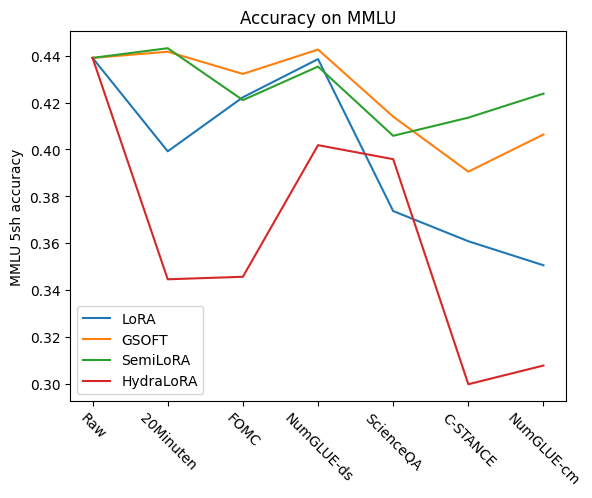

In [19]:
LoRA_scores = [total_res[total_res['run_name'] == 'Raw_5sh'].accuracy[0]]
LoRA_scores += [
    total_res[total_res['run_name'] == f'LoRA-{dataset_name}_5sh'].accuracy[0]
    for dataset_name in dataset_names
]

SemiLoRA_scores = [total_res[total_res['run_name'] == 'Raw_5sh'].accuracy[0]]
SemiLoRA_scores += [
    total_res[total_res['run_name'] == f'SemiLoRA-{dataset_name}_5sh'].accuracy[0]
    for dataset_name in dataset_names
]

HydraLoRA_scores = [total_res[total_res['run_name'] == 'Raw_5sh'].accuracy[0]]
HydraLoRA_scores += [
    total_res[total_res['run_name'] == f'HydraLoRA-{dataset_name}_5sh'].accuracy[0]
    for dataset_name in dataset_names
]

GSOFT_scores = [total_res[total_res['run_name'] == 'Raw_5sh'].accuracy[0]]
GSOFT_scores += [
    total_res[total_res['run_name'] == f'GSOFT-{dataset_name}_5sh'].accuracy[0]
    for dataset_name in dataset_names
]


plt.plot(
    range(len(dataset_names) + 1),
    LoRA_scores,
    label='LoRA'
)

plt.plot(
    range(len(dataset_names) + 1),
    GSOFT_scores,
    label='GSOFT'
)

plt.plot(
    range(len(dataset_names) + 1),
    SemiLoRA_scores,
    label='SemiLoRA'
)

plt.plot(
    range(len(dataset_names) + 1),
    HydraLoRA_scores,
    label='HydraLoRA'
)

plt.xticks(
    range(len(dataset_names) + 1),
    labels=['Raw'] + dataset_names,
    rotation=-45
)

plt.legend()

plt.title('Accuracy on MMLU')
plt.ylabel('MMLU 5sh accuracy')

Text(0, 0.5, 'MMLU 0sh accuracy')

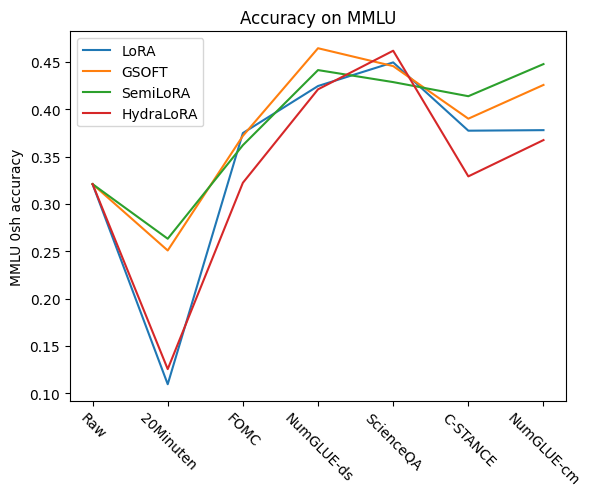

In [20]:
LoRA_scores = [total_res[total_res['run_name'] == 'Raw_0sh'].accuracy[0]]
LoRA_scores += [
    total_res[total_res['run_name'] == f'LoRA-{dataset_name}_0sh'].accuracy[0]
    for dataset_name in dataset_names
]

SemiLoRA_scores = [total_res[total_res['run_name'] == 'Raw_0sh'].accuracy[0]]
SemiLoRA_scores += [
    total_res[total_res['run_name'] == f'SemiLoRA-{dataset_name}_0sh'].accuracy[0]
    for dataset_name in dataset_names
]

HydraLoRA_scores = [total_res[total_res['run_name'] == 'Raw_0sh'].accuracy[0]]
HydraLoRA_scores += [
    total_res[total_res['run_name'] == f'HydraLoRA-{dataset_name}_0sh'].accuracy[0]
    for dataset_name in dataset_names
]

GSOFT_scores = [total_res[total_res['run_name'] == 'Raw_0sh'].accuracy[0]]
GSOFT_scores += [
    total_res[total_res['run_name'] == f'GSOFT-{dataset_name}_0sh'].accuracy[0]
    for dataset_name in dataset_names
]


plt.plot(
    range(len(dataset_names) + 1),
    LoRA_scores,
    label='LoRA'
)

plt.plot(
    range(len(dataset_names) + 1),
    GSOFT_scores,
    label='GSOFT'
)

plt.plot(
    range(len(dataset_names) + 1),
    SemiLoRA_scores,
    label='SemiLoRA'
)

plt.plot(
    range(len(dataset_names) + 1),
    HydraLoRA_scores,
    label='HydraLoRA'
)

plt.xticks(
    range(len(dataset_names) + 1),
    labels=['Raw'] + dataset_names,
    rotation=-45
)

plt.legend()

plt.title('Accuracy on MMLU')
plt.ylabel('MMLU 0sh accuracy')

In [ ]:
LoRA_scores = [total_res[total_res['run_name'] == 'Raw_5sh'].accuracy[0]]
LoRA_scores += [
    total_res[total_res['run_name'] == f'LoRA-{dataset_name}_5sh'].accuracy[0]
    for dataset_name in dataset_names
]

SemiLoRA_scores = [total_res[total_res['run_name'] == 'Raw_5sh'].accuracy[0]]
SemiLoRA_scores += [
    total_res[total_res['run_name'] == f'SemiLoRA-{dataset_name}_5sh'].accuracy[0]
    for dataset_name in dataset_names
]

HydraLoRA_scores = [total_res[total_res['run_name'] == 'Raw_5sh'].accuracy[0]]
HydraLoRA_scores += [
    total_res[total_res['run_name'] == f'HydraLoRA-{dataset_name}_5sh'].accuracy[0]
    for dataset_name in dataset_names
]

GSOFT_scores = [total_res[total_res['run_name'] == 'Raw_5sh'].accuracy[0]]
GSOFT_scores += [
    total_res[total_res['run_name'] == f'GSOFT-{dataset_name}_5sh'].accuracy[0]
    for dataset_name in dataset_names
]


plt.plot(
    range(len(dataset_names) + 1),
    LoRA_scores,
    label='LoRA'
)

plt.plot(
    range(len(dataset_names) + 1),
    GSOFT_scores,
    label='GSOFT'
)

plt.plot(
    range(len(dataset_names) + 1),
    SemiLoRA_scores,
    label='SemiLoRA'
)

plt.plot(
    range(len(dataset_names) + 1),
    HydraLoRA_scores,
    label='HydraLoRA'
)

plt.xticks(
    range(len(dataset_names) + 1),
    labels=['Raw'] + dataset_names,
    rotation=-45
)

plt.legend()

plt.title('Accuracy on MMLU')
plt.ylabel('MMLU 5sh accuracy')

In [21]:
assert False

AssertionError: 

In [ ]:
# scores = [total_res[total_res['run_name'] == 'LoRA_1b-CR'].accuracy[0]]
# scores += [
#     total_res[total_res['run_name'] == f'LoRA_1b-code st-{st}'].accuracy[0]
#     for st in range(2000, max_step+1,2000)
# ]

# sns.lineplot(
#     x=range(0, max_step+1, 2000),
#     y=scores,
#     label='fine-tuned'
# )

# sns.lineplot(
#     x=[0, max_step],
#     y=[total_res[total_res['run_name'] == 'Raw 1b'].accuracy.iloc[-1]] * 2,
#     linestyle='--',
#     label='Raw'
# )

# plt.xticks(
#     range(0, max_step+1,2000),
#     labels=['CR fine-tuned'] + [f'st-{st}' for st in range(2000, max_step+1,2000)],
#     rotation=-45
# )

# plt.title('LoRA tuning')
# plt.ylabel('MMLU 5sh accuracy')

In [ ]:
scores = [total_res[total_res['run_name'] == 'GSOFT_1b-CR'].accuracy[0]]
scores += [
    total_res[total_res['run_name'] == f'GSOFT_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=scores,
    label='fine-tuned'
)

sns.lineplot(
    x=[0, max_step],
    y=[total_res[total_res['run_name'] == 'Raw 1b'].accuracy.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(0, max_step+1,2000),
    labels=['CR fine-tuned'] + [f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('LoRA tuning')
plt.ylabel('MMLU 5sh accuracy')

In [ ]:
LoRA_scores = [total_res[total_res['run_name'] == 'LoRA_1b-CR'].accuracy[0]]
LoRA_scores += [
    total_res[total_res['run_name'] == f'LoRA_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

GSOFT_scores = [total_res[total_res['run_name'] == 'GSOFT_1b-CR'].accuracy[0]]
GSOFT_scores += [
    total_res[total_res['run_name'] == f'GSOFT_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=LoRA_scores,
    label='LoRA-tuned'
)

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=GSOFT_scores,
    label='GSOFT-tuned'
)

sns.lineplot(
    x=[0, max_step],
    y=[total_res[total_res['run_name'] == 'Raw 1b'].accuracy.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(0, max_step+1,2000),
    labels=['CR fine-tuned'] + [f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('Tuning')
plt.ylabel('MMLU 5sh accuracy')

In [ ]:
LoRA_scores = [
    total_res[total_res['run_name'] == f'LoRA_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

GSOFT_scores = [
    total_res[total_res['run_name'] == f'GSOFT_1b-code st-{st}'].accuracy[0]
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(2_000, max_step+1, 2000),
    y=LoRA_scores,
    label='LoRA-tuned'
)

sns.lineplot(
    x=range(2_000, max_step+1, 2000),
    y=GSOFT_scores,
    label='GSOFT-tuned'
)

sns.lineplot(
    x=[2_000, max_step],
    y=[total_res[total_res['run_name'] == 'Raw 1b'].accuracy.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(2_000, max_step+1,2000),
    labels=[f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('Tuning')
plt.ylabel('MMLU 5sh accuracy')

In [ ]:
GSOFT_loss = np.array([
    1.1026, 1.07861, 1.0576, 1.04731, 1.04182, 1.03851, 1.03722, 1.03678
])

plt.plot(GSOFT_loss)